### Setup

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import glob as glob
import json, sys
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parents[0]))


from utils.notebook import format_metric, display_plot

In [4]:
## Helper functions
def load_data(folder_path : str, x_metric, y_metric : str, label : str = None, skip_x : bool = False):
    """
    Load data for a certain `metric` from an inputted `folder_path`.

    Input: folder_path, metric, label

    Return: {x, y, label (inputted, if needed for a plt legend)}
    """
    filenames = glob.glob(folder_path)

    len(filenames)

    x, y= [], []

    for filename in filenames:
        with open(filename, 'r') as file:
            data = json.load(file)
            if not skip_x:
                x.append(data['kwargs'][x_metric])
            else:
                x.append(1)
            if y_metric == "timeElapsedSec":
                y.append(data[y_metric])
            else:
                y.append(data['metrics'][y_metric])
    
    # open clean data too
    parent_folder = "/".join(folder_path.split("/")[0:-2])
    with open(f"{parent_folder}/clean.json", 'r') as file:
        clean_data = json.load(file)
        x.append(0)
        y.append(clean_data['wrapper'][y_metric])

    print(len(x), len(y))
    x, y = zip(*sorted(zip(x, y))) # order the data correctly
    return {'x': x, 'y': y, 'label': label}


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, **styles):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    plt.plot(data['x'], data['y'], label=label, markersize=4, **styles)


## Displaying Score vs. Epsilon

###  Plot data comparing between FGSM vs. PGD

In [5]:
## Plot data comparing between FGSM vs. PGD
# Inputs
attack = "pgd-y-10"
metric = "f1"

# Plot data
data = {}
# fgsm
data[f"cpos-fgsm"] = load_data(folder_path=f"../final_data/constpos/fgsm-y/*", 
                                  metric=metric, 
                                  label="CPos FGSM")
data[f"rpos-fgsm"] = load_data(folder_path=f"../final_data/randpos/fgsm-y/*", 
                                  metric=metric, 
                                  label="RPos FGSM")
data[f"rspeed-fgsm"] = load_data(folder_path=f"../final_data/randspeed/fgsm-y/*", 
                                  metric=metric, 
                                  label="RSpeed FGSM")
# pgd
data[f"cpos-pgd"] = load_data(folder_path=f"../final_data/constpos/pgd-y-10/*", 
                                  metric=metric, 
                                  label="CPos PGD")
data[f"rpos-pgd"] = load_data(folder_path=f"../final_data/randpos/pgd-y-10/*", 
                                  metric=metric, 
                                  label="RPos PGD")
data[f"rspeed-pgd"] = load_data(folder_path=f"../final_data/randspeed/pgd-y-10/*", 
                                  metric=metric, 
                                  label="RSpeed PGD")

# FGSM: dashed lines, lighter shades
plot_data(data, "cpos-fgsm",   "#64B5F6", "o", "--")  # light blue,  circle
plot_data(data, "rspeed-fgsm", "#A5D6A7", "^", "--")  # light green, triangle
plot_data(data, "rpos-fgsm",   "#EF9A9A", "s", "--")  # light red,   square

# PGD: solid lines, darker shades of the same colors
plot_data(data, "cpos-pgd",    "#1565C0", "o", "-")   # dark blue,   circle
plot_data(data, "rspeed-pgd",  "#2E7D32", "^", "-")   # dark green,  triangle
plot_data(data, "rpos-pgd",    "#B71C1C", "s", "-")   # dark red,    square

# Plot the rest
display_metric  = prettify_metric(metric)
display_title = f"{display_metric} vs. Epsilon PGD"
prettify_plot(display_title, display_metric)

TypeError: load_data() got an unexpected keyword argument 'metric'

### Plot data comparing between PGD iters

30 30
30 30
30 30


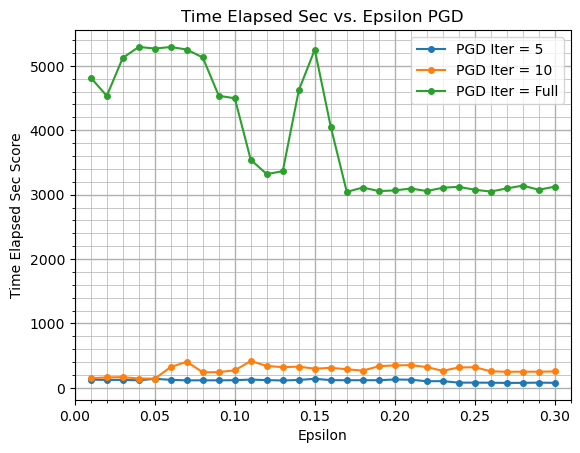

In [ ]:
## Plot data comparing between PGD iters
# Load data
for metric in ["timeElapsedSec"]:
    for scale in ["5", "10", "full"]:
        data[f"cpos-{scale}"] = load_data(f"../data_old/constpos-old/pgd-y-{scale}/*", metric, scale)

# Plot the rest
plt.plot(data["cpos-5"]['x'], data["cpos-5"]['y'],
         marker="o", markersize=4, label = "PGD Iter = 5")
plt.plot(data["cpos-10"]['x'], data["cpos-10"]['y'],
         marker="o", markersize=4, label = "PGD Iter = 10")
plt.plot(data["cpos-full"]['x'], data["cpos-full"]['y'],
         marker="o", markersize=4, label = "PGD Iter = Full")

# Plot the rest
display_metric  = format_metric(metric)
display_title = f"{display_metric} vs. Epsilon PGD"
display_plot(display_title, display_metric, limit=False)

### Plot for metric vs epsilon and different attack datasets

In [1]:
## Load Plot for metric vs epsilon and different attack datasets
# Inputs
attack = "pgd-10-2"
x_metric = "eps"
# y_metric = "f1"
# y_metric = "falsePositiveRate"
y_metric = "falseNegativeRate"

# Load data
data = {}
folder_names = ["constpos", "randpos", "randspeed"]
legend_names = ["Constant Pos", "Random Pos", "Random Speed"]

# folder_names = ["constpos"]
# legend_names = ["Constant Position"]

for folder in folder_names:
    data[folder] = load_data(f"../final_data/{folder}/{attack}/*", x_metric = x_metric, y_metric = y_metric)
    plt.plot(data[folder]['x'], data[folder]['y'],
             marker="o", markersize=4, label = legend_names[folder_names.index(folder)])

# Plot the rest
display_metric  = prettify_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon PGD"
prettify_plot(display_title, display_metric, x_max=0.5, limit=True)

NameError: name 'load_data' is not defined

### Plot for adv trained

31 31


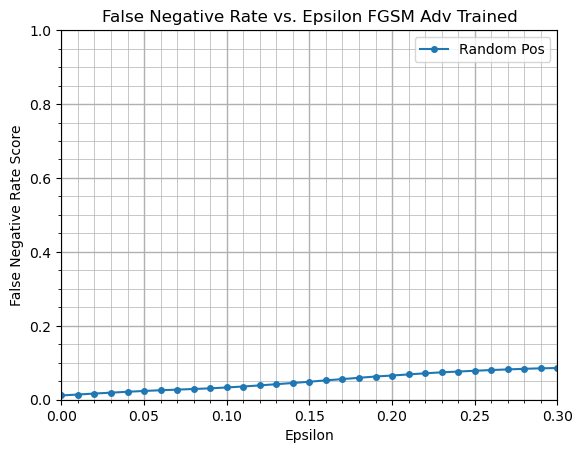

In [ ]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
folder = "randpos_pgd-0.05_epochs-5_trained-30-30-20"
# y_metric = "f1"

# Load data
data = {}
data["rpos"] = load_data(f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-30/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
# Plot Epsilon
plt.plot(data["rpos"]['x'], data["rpos"]['y'],
         marker="o", markersize=4, label = "Random Pos")

# Plot the rest
display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon FGSM Adv Trained"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 1))

51 51
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31
31 31


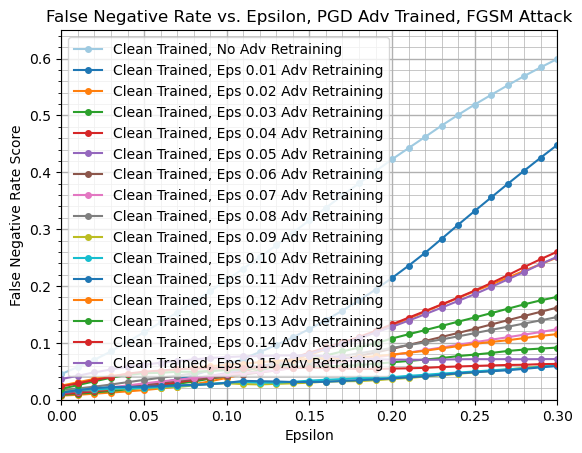

In [6]:
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"

load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#9ECAE1"
)
for i in range(1, 16):
    eps = float(i/100)
    load_plot(
        folder=f"../defenses/fed/data-test/8-5-26/randpos_pgd-{eps:.2f}_epochs-5_clean/{attack}/*",
        x_metric = x_metric, y_metric = y_metric,
        label = f"Clean Trained, Eps {eps:.2f} Adv Retraining",
        marker="o", linestyle="-"
    )

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.65))


51 51


FileNotFoundError: [Errno 2] No such file or directory: '../defenses/fed/fed/data-test/randpos_pgd-0.08_epochs-5_trained-30-30-200_ratio-0.5/clean.json'

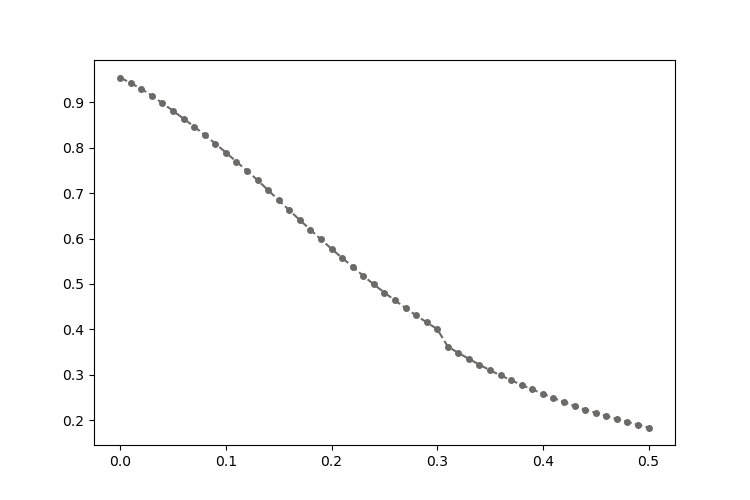

In [ ]:
# Requires: pip install mplcursors ipympl
%matplotlib widget
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
import mplcursors

attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
# y_metric = "f1" 
y_metric = "recall" 


seq_cmap = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)
# eps_values = [i / 100 for i in range(1, 16)]
eps_values = [0.08, 0.10, 0.12, 0.99]
# Discrete bins, one per eps value, so each line's shade maps to exactly one
# labeled colorbar tick instead of an interpolated position on a gradient.
bounds = [v - 0.005 for v in eps_values] + [eps_values[-1] + 0.005]
norm = BoundaryNorm(bounds, seq_cmap.N)

fig, ax = plt.subplots(figsize=(7.5, 5))

all_data = {"x": [], "y": []}
# baseline = load_data(f"../attacks/fed/fed/final_data/randpos/{attack}/*",

baseline = load_data(f"../attacks/fed/final_data/randpos/{attack}/*",
                      x_metric=x_metric, y_metric=y_metric)
baseline_line, = ax.plot(baseline['x'], baseline['y'],
          marker="o", markersize=4, linestyle="--", color="#6b6a67",
          label="No Adv Retraining", zorder=3)
all_data['x'].append(0)
all_data['y'].append(baseline['y'][0])
line_labels = {baseline_line: "No Adv Retraining"}


for eps in eps_values:
    data = load_data(
        f"../defenses/fed/fed/data-test/randpos_evasion_pgd-{eps:.2f}_epochs-5_trained-30-30-200_ratio-0.5/{attack}/*",
        x_metric=x_metric, y_metric=y_metric
    )

    all_data['x'].append(eps)
    all_data['y'].append(data['y'][0])

    line, = ax.plot(data['x'], data['y'],
              marker="o", markersize=3, linestyle="-",
              color=seq_cmap(norm(eps)), linewidth=1.5, zorder=2)
    line_labels[line] = f"Train \u03b5 = {eps:.2f}"

sm = cm.ScalarMappable(cmap=seq_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, label="Training \u03b5 (PGD)", ticks=eps_values)
cbar.ax.set_yticklabels([f"{v:.2f}" for v in eps_values])

ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.set_xlim(0, 0.3)
ax.set_ylim(0, 1.0)
display_metric = format_metric(y_metric)
ax.set_xlabel(format_metric(x_metric))
ax.set_ylabel(f"{display_metric} Score")
ax.set_title(f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack")
ax.grid(True)

# Hover tooltip: shows the exact training eps for whichever line is under the cursor.
cursor = mplcursors.cursor(list(line_labels.keys()), hover=True)

@cursor.connect("add")
def _on_hover(sel):
    label = line_labels[sel.artist]
    x_val, y_val = sel.target
    sel.annotation.set_text(f"{label}\n{x_metric} = {x_val:.2f}\n{y_metric} = {y_val:.3f}")
    sel.annotation.get_bbox_patch().set(fc="white", alpha=0.9)

plt.show()


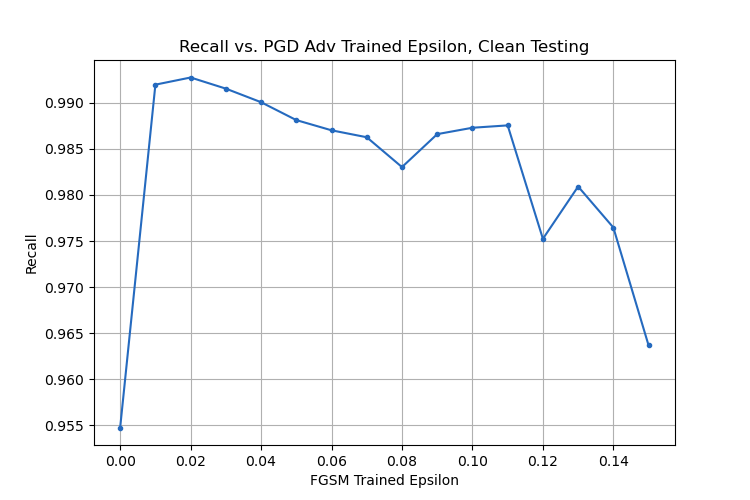

In [40]:
figure = plt.figure(figsize=(7.5, 5))

plt.plot(all_data['x'], all_data['y'], marker="o", markersize=3, linestyle="-", color="#256abf", linewidth=1.5, zorder=2)
plt.xlabel("FGSM Trained Epsilon")
plt.ylabel(format_metric(y_metric))
plt.title(f"{format_metric(y_metric)} vs. PGD Adv Trained Epsilon, Clean Testing")
plt.grid(True)
plt.show()

51 51
31 31
31 31
31 31
34 34
31 31


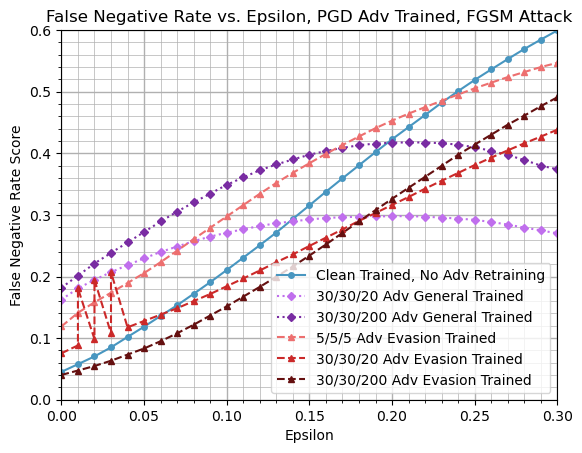

In [17]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
# y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"

# Load data

# clean
load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#4896C0"
)
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-5/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "Clean Trained, 5 Epochs Retraining",
#     marker="s", linestyle="-", color="#4292C6"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos-pgd-0.05-epochs-30/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "Clean Trained, 30 Epochs Retraining",
#     marker="^", linestyle="-", color="#08519C"
# )

# 30/30/20
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, No Adv Retraining",
#     marker="v", linestyle=":", color="#FD8D3C"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-20/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, 5 Epochs Retraining",
#     marker="D", linestyle=":", color="#E6550D"
# )
# load_plot(
#     folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-20/{attack}/*",
#     x_metric = x_metric, y_metric = y_metric,
#     label = "30/30/20 Adv Trained, 30 Epochs Retraining",
#     marker="D", linestyle=":", color="#A63603"
# )

# 30/30/200

load_plot(
    folder=f"../defenses/fed/data-test/8-4-26/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv General Trained",
    marker="D", linestyle=":", color="#c06fed"
)

load_plot(
    folder=f"../defenses/fed/data-test/8-4-26/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv General Trained",
    marker="D", linestyle=":", color="#792ca2"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-5-5-5_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "5/5/5 Adv Evasion Trained",
    marker="^", linestyle="--", color="#ed6f6f"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Evasion Trained",
    marker="^", linestyle="--", color="#cb2929"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos-evasion_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Evasion Trained",
    marker="^", linestyle="--", color="#651010"
)

# 7d32a8

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.6))
plt.show()

51 51
31 31
31 31


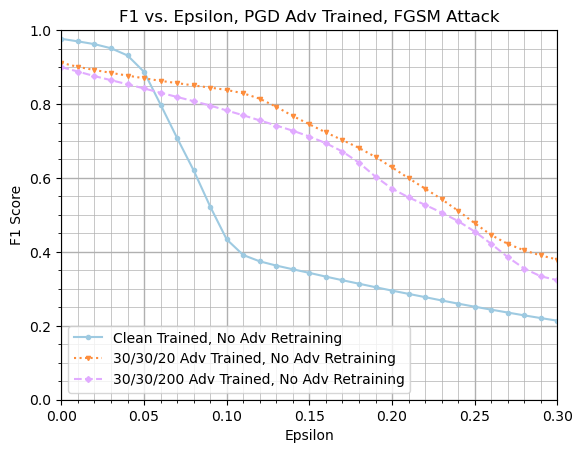

In [ ]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
# y_metric = "falseNegativeRate"
y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, marker : str = "o", linestyle : str = "-", color = None):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    if color:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=3, label = label, linestyle=linestyle, color=color)
    else:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=4, label = label, linestyle=linestyle)


# Load data
load_plot(
    folder=f"../attacks/fed/final_data/randpos/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "Clean Trained, No Adv Retraining",
    marker="o", linestyle="-", color="#9ECAE1"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, No Adv Retraining",
    marker="v", linestyle=":", color="#FD8D3C"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, No Adv Retraining",
    marker="D", linestyle="--", color="#e1abff"
)


display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 1))

31 31
31 31
31 31
31 31
31 31
31 31


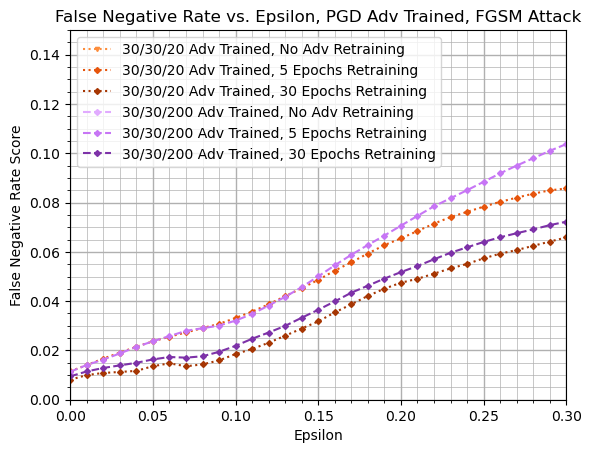

In [91]:
## Load Plot for adv trained
# Inputs
attack = "fgsm"
x_metric = "eps"
y_metric = "falseNegativeRate"
# y_metric = "f1"
folder = ""
# folder = "randpos-pgd-0.05-epochs-5"


def load_plot(folder : str, x_metric : str, y_metric : str, label : str, marker : str = "o", linestyle : str = "-", color = None):
    data = load_data(folder, x_metric = x_metric, y_metric = y_metric)
    if color:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=3, label = label, linestyle=linestyle, color=color)
    else:
        plt.plot(data['x'], data['y'],
            marker=marker, markersize=4, label = label, linestyle=linestyle)


# Load data

# 30/30/20
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-20_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, No Adv Retraining",
    marker="v", linestyle=":", color="#FD8D3C"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-20/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, 5 Epochs Retraining",
    marker="D", linestyle=":", color="#E6550D"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-20/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/20 Adv Trained, 30 Epochs Retraining",
    marker="D", linestyle=":", color="#A63603"
)

# 30/30/200
load_plot(
    folder=f"../defenses/fed/data-test/randpos_trained-30-30-200_no-retraining/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, No Adv Retraining",
    marker="D", linestyle="--", color="#e1abff"
)

load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-5_trained-30-30-200/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, 5 Epochs Retraining",
    marker="D", linestyle="--", color="#c776f5"
)
load_plot(
    folder=f"../defenses/fed/data-test/randpos_pgd-0.05_epochs-30_trained-30-30-200/{attack}/*",
    x_metric = x_metric, y_metric = y_metric,
    label = "30/30/200 Adv Trained, 30 Epochs Retraining",
    marker="D", linestyle="--", color="#7d32a8"
)


# 7d32a8

display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Epsilon, PGD Adv Trained, FGSM Attack"
display_plot(display_title, display_metric, x=(0, 0.3), y = (0, 0.15))

## JSMA: F1 vs. Gamma

In [6]:
# 1. Load data
foldername = "../final_data/randspeed/jsma/*"
filenames = glob.glob(foldername)

len(filenames)

10

In [58]:
## Load Plot for adv trained
# Inputs
attack = "jsma"
x_metric = "gamma"
y_metric = "falseNegativeRate"
# y_metric = "f1"

# Load data
data = {}
data["rspeed"] = load_data(f"../final_data/randspeed/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
data["rpos"] = load_data(f"../final_data/randpos/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
data["cpos"] = load_data(f"../final_data/constpos/{attack}/*", 
                         x_metric = x_metric,
                         y_metric = y_metric)
# Plot Epsilon
plt.plot(data["cpos"]['x'], data["cpos"]['y'],
         marker="o", markersize=4, label = "Constant Pos")
plt.plot(data["rpos"]['x'], data["rpos"]['y'],
         marker="o", markersize=4, label = "Random Pos")

plt.plot(data["rspeed"]['x'], data["rspeed"]['y'],
         marker="o", markersize=4, label = "Random Speed")



# Plot the rest
display_metric  = format_metric(y_metric)
display_title = f"{display_metric} vs. Gamma JSMA"
display_plot(display_title, display_metric, 
             x=(-0.05, 1.05), y=(-0.05, 1.05),
             x_metric=format_metric(x_metric))



FileNotFoundError: [Errno 2] No such file or directory: '../final_data/randspeed/clean.json'

## Displaying F1 Score vs. Run type

In [22]:
cat_vals = {}
for filename in filenames:
    with open(filename, 'r') as file:
        data = json.load(file)
        print(data)
        norm_type = "Denorm" if "denorm" in filename else "Norm"
        
        # Loop through each run and average the results
        for run in (data["benign"]):
            wrapper_type = "Wrapper" if run["wrapper"] else "Og"
            collapsed_type = "Collapsed" if run["collapsedOutput"] else "Uncollapsed"
            key = f"{norm_type}-{wrapper_type}-{collapsed_type}"

            # if not key in cat_vals.keys():
            #     cat_vals[key] = []

            cat_vals[key] = (run["f1"])


cat_vals

{'benign': [{'wrapper': False, 'collapsedOutput': False, 'accuracy': 0.9828824723807696, 'precision': 0.9641379419885481, 'recall': 0.978858930529575, 'f1': 0.9714426699563232}, {'wrapper': False, 'collapsedOutput': True, 'accuracy': 0.9832112459326462, 'precision': 0.9643128342104006, 'recall': 0.9797491232802805, 'f1': 0.9719696949422882}, {'wrapper': True, 'collapsedOutput': False, 'accuracy': 0.9828824723807696, 'precision': 0.9830044252696218, 'recall': 0.9828824723807696, 'f1': 0.9829195656898114}, {'wrapper': True, 'collapsedOutput': True, 'accuracy': 0.9961931171558177, 'precision': 0.9961990861326315, 'recall': 0.9961931171558177, 'f1': 0.9961883773969892}]}
{'benign': [{'wrapper': False, 'collapsedOutput': False, 'accuracy': 0.9917490823408723, 'precision': 0.9921024389045001, 'recall': 0.9800296735905044, 'f1': 0.9860291034334886}, {'wrapper': False, 'collapsedOutput': True, 'accuracy': 0.9917490823408723, 'precision': 0.9921024389045001, 'recall': 0.9800296735905044, 'f1': 

{'Denorm-Og-Uncollapsed': 0.9714426699563232,
 'Denorm-Og-Collapsed': 0.9719696949422882,
 'Denorm-Wrapper-Uncollapsed': 0.9829195656898114,
 'Denorm-Wrapper-Collapsed': 0.9961883773969892,
 'Norm-Og-Uncollapsed': 0.9860291034334886,
 'Norm-Og-Collapsed': 0.9860291034334886,
 'Norm-Wrapper-Uncollapsed': 0.9917344098986437,
 'Norm-Wrapper-Collapsed': 0.997697250661112}

In [7]:
cat_vals = {"Denorm-Wrapper-Collapsed": 0.9557423970602369, "Norm-Wrapper-Collapsed": 0.15478531634773934}

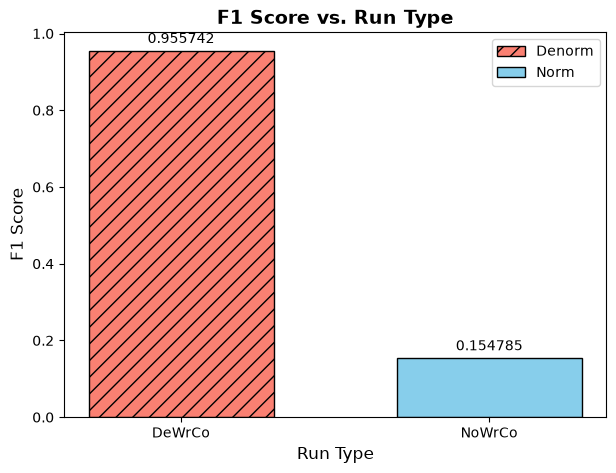

In [8]:
cats = list(cat_vals.keys())
vals = list(cat_vals.values())

color_map = {'Denorm': 'salmon', 'Norm': 'skyblue'}
hatch_map = {'Denorm': '//', 'Norm': ''}

colors  = [color_map['Denorm' if k.startswith('Denorm') else 'Norm'] for k in cats]
hatches = [hatch_map['Denorm' if k.startswith('Denorm') else 'Norm'] for k in cats]

fig, ax = plt.subplots(figsize=(7, 5))

bar_cats = []

for k in cats:
    norm_type = "De" if "Denorm" in k else "No"
    wrapper_type = "Wr" if "Wrapper" in k else "Og"
    collapsed_type = "Un" if "Uncollapsed" in k else "Co"
    bar_cats.append(f"{norm_type}{wrapper_type}{collapsed_type}")

 
bars = ax.bar(bar_cats, vals, width=0.6, color=colors, hatch=hatches, edgecolor='black')
ax.bar_label(bars, padding=3)
# ax.set_ylim(0.96, 1.0)

ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='salmon',  edgecolor='black', hatch='//', label='Denorm'),
    Patch(facecolor='skyblue', edgecolor='black', label='Norm'),
]
ax.legend(handles=legend_elements)


dict_keys(['Denorm-Wrapper-Uncollapsed', 'Denorm-Og-Uncollapsed', 'Denorm-Og-Collapsed', 'Denorm-Wrapper-Collapsed', 'Norm-Wrapper-Uncollapsed', 'Norm-Og-Uncollapsed', 'Norm-Og-Collapsed', 'Norm-Wrapper-Collapsed']) dict_values([0.9829195656898114, 0.9714426699563232, 0.9719696949422882, 0.9961883773969892, 0.9917344098986437, 0.9860291034334886, 0.9860291034334886, 0.997697250661112])


Text(0.5, 1.0, 'F1 Score vs. Run Type')

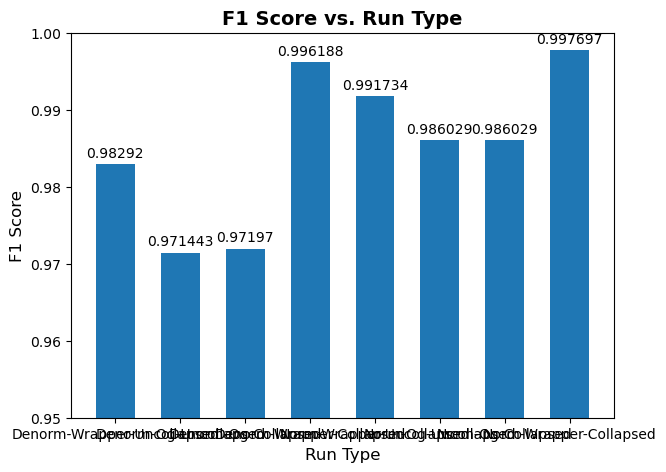

In [ ]:
cats = cat_vals.keys()
vals = cat_vals.values()
print(cats, vals)
# Create figure and axis
fig, ax = plt.sub
bplots(figsize=(7, 5))

# Plot vertical bars
bars = ax.bar(cats, vals, width=0.6)
ax.bar_label(bars, padding=3)
ax.set_ylim(0.95, 1.0)

# Customizing labels and title
ax.set_xlabel('Run Type', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('F1 Score vs. Run Type', fontsize=14, fontweight='bold')

## Graph for CW

In [47]:
## Load Plot for metric vs epsilon and different attack datasetsß
# Inputs
attack = "cw"
x_metric = ""
# y_metric = "falsePositiveRate"
y_metric = "f1"


# Load data
data = {}
folder_names = ["randpos", "constpos", "randspeed"]
legend_names = ["Random Position", "Constant Position", "Random Speed"]

# folder_names = ["constpos"]
# legend_names = ["Constant Position"]

for folder in folder_names:
    data[folder] = load_data(f"../final_data/{folder}/{attack}/*", x_metric = x_metric, y_metric = y_metric, skip_x=True)

y_values = [v["y"][0] for v in data.values()]          # list of tuples, e.g. [(0.42,), (0.35,), (0.24,)]


2 2
2 2
2 2


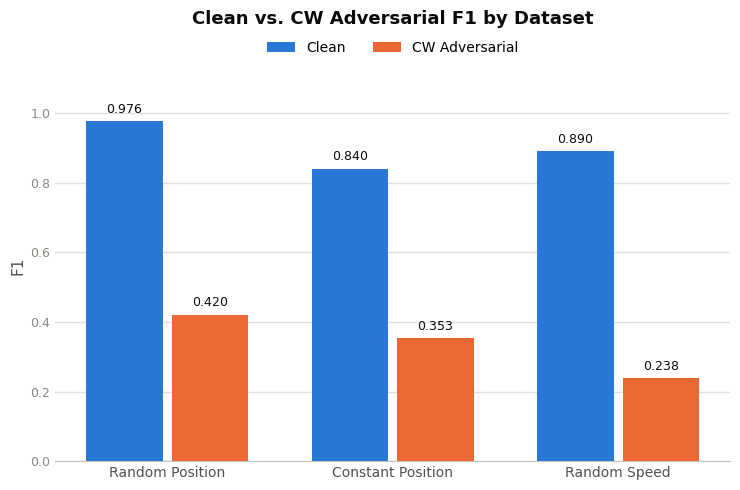

In [48]:
import numpy as np

display_names = {"randpos": "Random Position", "constpos": "Constant Position", "randspeed": "Random Speed"}
categories = list(data.keys())
labels = [display_names.get(c, c) for c in categories]

clean_vals = [data[c]["y"][0] for c in categories]
adv_vals   = [data[c]["y"][1] for c in categories]

x = np.arange(len(categories))
width = 0.34

fig, ax = plt.subplots(figsize=(7.5, 5))

# Categorical palette slots 1-2 (blue, orange) - one hue per series, fixed across groups
bars_clean = ax.bar(x - width/2 - 0.02, clean_vals, width, label="Clean", color="#2a78d6", edgecolor="none", zorder=3)
bars_adv   = ax.bar(x + width/2 + 0.02, adv_vals,   width, label="CW Adversarial", color="#eb6834", edgecolor="none", zorder=3)

ax.bar_label(bars_clean, fmt="%.3f", padding=4, fontsize=9, color="#0b0b0b")
ax.bar_label(bars_adv,   fmt="%.3f", padding=4, fontsize=9, color="#0b0b0b")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, color="#52514e")
ax.set_ylim(0, 1.12)
display_metric  = format_metric(y_metric)
ax.set_ylabel(display_metric, fontsize=11, color="#52514e")
ax.set_title(f"Clean vs. CW Adversarial {display_metric} by Dataset", fontsize=13, fontweight="bold", color="#0b0b0b", pad=34)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", labelsize=9, colors="#898781", length=0)

# Recessive gridlines, no border box
ax.yaxis.grid(True, color="#e1e0d9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")

# Two series -> legend is required (identity isn't color-alone); placed above to avoid bar collisions
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2, frameon=False, fontsize=10)

fig.tight_layout()
plt.show()